# **Experiments with MNIST, PCA, and Cones (MODULARIZING + FACT 3.2)**

## **Imports**

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

import numpy as np
from numpy.linalg import pinv
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch, numpy as np, random


## **Function Definitions**

In [15]:
def load_mnist_subset(selected_digits, batch_size=256):
    # Select Digits
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------

    Q = len(selected_digits)     # number of classes
    L = Q + 1                    # total layers

    print(f"Using digits: {selected_digits} | Q = {Q} | L = {L}")

    # Preprocess Digits
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 to 784
    ])

    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


    train_mask = torch.zeros_like(train_dataset.targets, dtype=torch.bool)
    test_mask = torch.zeros_like(test_dataset.targets, dtype=torch.bool)


    for digit in selected_digits:
        train_mask |= (train_dataset.targets == digit)
        test_mask |= (test_dataset.targets == digit)

    # create filters
    train_dataset.targets = train_dataset.targets[train_mask]
    train_dataset.data    = train_dataset.data[train_mask]
    test_dataset.targets = test_dataset.targets[test_mask]
    test_dataset.data    = test_dataset.data[test_mask]

    # remap labels to {0,...,Q-1}
    label_map = {digit: idx for idx, digit in enumerate(selected_digits)}
    train_dataset.targets = torch.tensor([label_map[label.item()] for label in train_dataset.targets])
    test_dataset.targets = torch.tensor([label_map[label.item()] for label in test_dataset.targets])


    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, label_map, Q, L

In [16]:
# ReLU Feedforward Network
class ReluNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[10, 10, 10], output_dim=3): # 3 hidden layers (Q) + 1 output layer, should output_dim be 3 or 10?
        super().__init__()
        dims = [input_dim] + hidden_dims + [output_dim]
        self.layers = nn.ModuleList([
            nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)
        ])

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)

In [17]:
# Leaky ReLU Feedforward Network
class LeakyReluNet(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[10, 10, 10], output_dim=3): # 3 hidden layers (Q) + 1 output layer, should output_dim be 3 or 10?
        super().__init__()
        dims = [input_dim] + hidden_dims + [output_dim]
        self.layers = nn.ModuleList([
            nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)
        ])

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.leaky_relu(layer(x))
        return self.layers[-1](x)

In [18]:
def one_hot(labels, num_classes):
    return torch.nn.functional.one_hot(labels, num_classes=num_classes).float()

In [19]:
def train_and_evaluate(model, train_loader, test_loader, Q, epochs=200, lr=0.005, momentum=0.9):
    #print(model)

    # Train network
    criterion = nn.MSELoss()  # squared L2 loss, matches the paper
    #criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    for epoch in range(epochs):
        model.train()
        for data, target in train_loader:
            optimizer.zero_grad()

            # One-hot encode the labels
            target_onehot = one_hot(target, num_classes=Q)

            output = model(data)
            loss = criterion(output, target_onehot)
            #loss = criterion(output, target)

            loss.backward()
            optimizer.step()

        if epoch % 10 == 0:
            print(f'Epoch {epoch+1}, MSE Loss: {loss.item():.4f}')

    print(f"Final MSE Loss: {loss.item():.6f}")

    # Test accuracy: predict with argmax as usual
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    test_acc = correct / total
    print(f"Test Accuracy: {test_acc * 100:.2f}%\n")

    return model, test_acc

In [20]:
def extract_and_compute_cumulative(model):
    # Extracting weights and biases
    Ws = []
    bs = []
    for layer in model.layers:
        Ws.append(layer.weight.detach().clone())
        bs.append(layer.bias.detach().clone())

    L = len(Ws)  # should equal Q+1
    L1 = len(bs) # should equal Q+1

    print("Weights Length: ", L)
    print("Biases Length: ", L1)

    W_cum_chain = []
    b_cum_chain = []

    for ell in range(L):  # loop through each layer
        if ell == 0:
            # for the first layer, cumulative weight and bias are just themselves
            Wcum = Ws[0]
            bcum = bs[0]
        else:
            # multiply the current layer's weight by the total weight so far
            Wcum = Ws[ell] @ W_cum_chain[-1]

            # for the bias:
            # start at zero, and for each previous bias, multiply it by all the weights that come after it
            btemp = 0
            for k in range(ell):
                chain = Ws[ell]
                for j in range(ell-1, k, -1):
                    chain = chain @ Ws[j]
                btemp += chain @ bs[k]

            # finally add the current layer's bias
            bcum = btemp + bs[ell]

        W_cum_chain.append(Wcum)
        b_cum_chain.append(bcum)

    return Ws, bs, W_cum_chain, b_cum_chain

In [21]:
def collect_dataset(loader):
    X_train = []
    y_train = []

    for data, labels in loader:
        X_train.append(data)
        y_train.append(labels)

    X_train = torch.cat(X_train, dim=0).numpy()
    y_train = torch.cat(y_train, dim=0).numpy()

    return X_train, y_train

In [22]:
# ---------------------------------------------------------
# Definition of the truncation map (with ReLU)
# ---------------------------------------------------------

def tau(X_train, Wcum_chain, bcum_chain):
    layers = len(Wcum_chain)
    X_trunc_chain = [X_train]  # I CHANGED THIS (MAYANK)
    # X_trunc_chain = []

    for ell in range(layers):
        # Get cumulative parameters for layer ell: W^(ell) and b^(ell)
        Wcum = Wcum_chain[ell].detach().cpu().numpy()
        bcum = bcum_chain[ell].detach().cpu().numpy()

        # Compute pseudoinverse of W^(ell)
        W_pinv = np.linalg.pinv(Wcum)

        # Compute pre-activation: Z = X * W^T + b
        Z = X_trunc_chain[ell] @ Wcum.T + bcum # I CHANGED THIS (MAYANK)
        # Z = X_train @ Wcum.T + bcum

        # Apply ReLU nonlinearity: max(0, Z)
        Z_relu = np.maximum(Z, 0)

        # Apply truncation map definition:
        # τ_{W,b}(x) = W^(-1) (ReLU(Wx + b) - b)
        X_trunc = (W_pinv @ (Z_relu.T - bcum[:, np.newaxis])).T

        # Store truncated data for this layer
        X_trunc_chain.append(X_trunc)

        # Print shape for confirmation
        print(f"Truncated data for layer {ell+1}: {X_trunc.shape}")

    return X_trunc_chain[1:]

In [23]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

## **PCA Visualization**

In [24]:
def plot_global_pca(X_train, X_trunc_chain, y_train, label_map, model, Q):
    # labels
    inv_map = {v: k for k, v in label_map.items()}
    label_names = np.array([f"{inv_map[y]} (→ {y})" for y in y_train])

    # fit PCA on original data
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))  # 2 row, 2 columns (this is for making sure all truncation plots can be viewed together)
    axes = axes.flatten()  # flatten for easy indexing

    # Original data
    df = pd.DataFrame({
        "PCA1": X_train_pca[:, 0],
        "PCA2": X_train_pca[:, 1],
        "Label": label_names
    })
    sns.scatterplot(
        data=df, x="PCA1", y="PCA2", hue="Label",
        palette='Set1', s=10, alpha=0.7, ax=axes[0]
    )
    axes[0].set_title("Original Data (PCA Projection)")
    axes[0].grid(True)

    # ---------------------------------------------------------
    # Project truncated data in same PCA frame & plot (2x2 grid)
    # ---------------------------------------------------------

    for ell, X_trunc in enumerate(X_trunc_chain[:Q]):
        X_pca = pca.transform(X_trunc)
        df_trunc = pd.DataFrame({
            "PCA1": X_pca[:, 0],
            "PCA2": X_pca[:, 1],
            "Label": label_names
        })
        sns.scatterplot(
            data=df_trunc, x="PCA1", y="PCA2",
            hue="Label", palette='Set1', s=10, alpha=0.7, ax=axes[ell+1]
        )
        axes[ell+1].set_title(f"(Global PCA) Truncated Data after Layer {ell+1}")
        axes[ell+1].grid(True)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Plot final output in R^Q (no PCA needed)
    # ---------------------------------------------------------

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    model.eval() # Set model to evaluation mode and disable gradients
    with torch.no_grad():
        X_out = model(X_train_tensor).numpy() # Forward pass to get final output logits

    print(f"Output layer shape: {X_out.shape}")

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    for c in np.unique(y_train): # Loop through each class to plot its points
        idx = y_train == c
        ax.scatter(
            X_out[idx, 0], X_out[idx, 1], X_out[idx, 2],
            label=f"Class {c}", s=10
        )

    ax.set_title("Final Output Layer in R^3")
    ax.set_xlabel("Output 1")
    ax.set_ylabel("Output 2")
    ax.set_zlabel("Output 3")
    ax.legend()
    plt.show()

In [25]:
def plot_local_pca(X_train, X_trunc_chain, y_train, label_map, model, Q):
    # labels
    inv_map = {v: k for k, v in label_map.items()}
    label_names = np.array([f"{inv_map[y]} (→ {y})" for y in y_train])

    # ---------------------------------------------------------
    # PCA on original data (local to original)
    # ---------------------------------------------------------

    pca_orig = PCA(n_components=2)
    X_train_pca = pca_orig.fit_transform(X_train)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    # Original data
    df = pd.DataFrame({
        "PCA1": X_train_pca[:, 0],
        "PCA2": X_train_pca[:, 1],
        "Label": label_names
    })
    sns.scatterplot(
        data=df, x="PCA1", y="PCA2", hue="Label",
        palette='Set1', s=10, alpha=0.7, ax=axes[0]
    )
    axes[0].set_title("Original Data (Local PCA)")
    axes[0].grid(True)

    # ---------------------------------------------------------
    # Local PCA on each truncated dataset
    # ---------------------------------------------------------

    for ell, X_trunc in enumerate(X_trunc_chain[:Q]):
        local_pca = PCA(n_components=2)
        X_trunc_pca = local_pca.fit_transform(X_trunc)

        df_trunc = pd.DataFrame({
            "PCA1": X_trunc_pca[:, 0],
            "PCA2": X_trunc_pca[:, 1],
            "Label": label_names
        })

        sns.scatterplot(
            data=df_trunc, x="PCA1", y="PCA2",
            hue="Label", palette='Set1', s=10, alpha=0.7, ax=axes[ell+1]
        )

        axes[ell+1].set_title(f"(Local PCA) Truncated Data after Layer {ell+1}")
        axes[ell+1].grid(True)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Plot final output in R^Q (no PCA needed)
    # ---------------------------------------------------------

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        X_out = model(X_train_tensor).numpy()

    print(f"Output layer shape: {X_out.shape}")

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for c in np.unique(y_train):
        idx = y_train == c
        ax.scatter(
            X_out[idx, 0], X_out[idx, 1], X_out[idx, 2],
            label=f"Class {c}", s=10
        )

    ax.set_title("Final Output Layer in R^3")
    ax.set_xlabel("Output 1")
    ax.set_ylabel("Output 2")
    ax.set_zlabel("Output 3")
    ax.legend()
    plt.show()

In [43]:
def plot_barycentric_projection(X_train, X_trunc_chain, y_train, label_map, model, Q):
    # labels
    inv_map = {v: k for k, v in label_map.items()}
    label_names = np.array([f"{inv_map[y]} (→ {y})" for y in y_train])

    # ---------------------------------------------------------
    # Global PCA on original data (baseline)
    # ---------------------------------------------------------
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    # Original data
    df_orig = pd.DataFrame({
        "PCA1": X_train_pca[:, 0],
        "PCA2": X_train_pca[:, 1],
        "Label": label_names
    })
    sns.scatterplot(
        data=df_orig, x="PCA1", y="PCA2",
        hue="Label", palette='Set1', s=10, alpha=0.7, ax=axes[0]
    )
    axes[0].set_title("Original Data (PCA Projection)")
    axes[0].grid(True)

    # ---------------------------------------------------------
    # Barycentric projection for each truncated layer
    # ---------------------------------------------------------
    class_labels = np.unique(y_train)

    for ell, X_trunc in enumerate(X_trunc_chain[:Q]):
        # Compute class means
        means = np.vstack([
            X_trunc[y_train == c].mean(axis=0)
            for c in class_labels
        ])  # shape (C, d)

        # Reference class (first one)
        ref = means[0]

        # Mean-difference directions
        W_proj = np.vstack([
            means[i] - ref for i in range(1, len(means))
        ]).T  # shape (d, C-1)

        # Project data
        X_proj = X_trunc @ W_proj  # shape (N, C-1)

        # Pad to 2D if needed
        if X_proj.shape[1] == 1:
            X_proj = np.hstack([X_proj, np.zeros_like(X_proj)])

        # Plot
        df_bary = pd.DataFrame({
            "Dir1": X_proj[:, 0],
            "Dir2": X_proj[:, 1],
            "Label": label_names
        })

        sns.scatterplot(
            data=df_bary, x="Dir1", y="Dir2",
            hue="Label", palette='Set1', s=10, alpha=0.7, ax=axes[ell+1]
        )

        axes[ell+1].set_title(f"Barycentric Projection after Layer {ell+1}")
        axes[ell+1].grid(True)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Final output layer visualization
    # ---------------------------------------------------------
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        X_out = model(X_train_tensor).numpy()

    print(f"Output layer shape: {X_out.shape}")

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for c in np.unique(y_train):
        idx = y_train == c
        ax.scatter(
            X_out[idx, 0], X_out[idx, 1], X_out[idx, 2],
            label=f"Class {c}", s=10
        )

    ax.set_title("Final Output Layer in R^3")
    ax.set_xlabel("Output 1")
    ax.set_ylabel("Output 2")
    ax.set_zlabel("Output 3")
    ax.legend()
    plt.show()

In [44]:
def plot_lda_projection(X_train, X_trunc_chain, y_train, label_map, model, Q):
    # labels
    inv_map = {v: k for k, v in label_map.items()}
    label_names = np.array([f"{inv_map[y]} (→ {y})" for y in y_train])

    # ---------------------------------------------------------
    # Fit LDA on original data
    # ---------------------------------------------------------
    lda = LDA(n_components=2)
    X_train_lda = lda.fit_transform(X_train, y_train)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    # ---------------------------------------------------------
    # Plot original data
    # ---------------------------------------------------------
    df_orig = pd.DataFrame({
        "LDA1": X_train_lda[:, 0],
        "LDA2": X_train_lda[:, 1],
        "Label": label_names
    })
    sns.scatterplot(
        data=df_orig, x="LDA1", y="LDA2",
        hue="Label", palette='Set1', s=10, alpha=0.7, ax=axes[0]
    )
    axes[0].set_title("Original Data (LDA Projection)")
    axes[0].grid(True)

    # ---------------------------------------------------------
    # Project truncated data using SAME LDA basis
    # ---------------------------------------------------------
    for ell, X_trunc in enumerate(X_trunc_chain[:Q]):
        X_trunc_lda = lda.transform(X_trunc)

        # pad to 2D if needed
        if X_trunc_lda.shape[1] == 1:
            X_trunc_lda = np.hstack([X_trunc_lda, np.zeros_like(X_trunc_lda)])

        df_trunc = pd.DataFrame({
            "LDA1": X_trunc_lda[:, 0],
            "LDA2": X_trunc_lda[:, 1],
            "Label": label_names
        })

        sns.scatterplot(
            data=df_trunc, x="LDA1", y="LDA2",
            hue="Label", palette='Set1', s=10, alpha=0.7, ax=axes[ell+1]
        )

        axes[ell+1].set_title(f"LDA Projection after Layer {ell+1}")
        axes[ell+1].grid(True)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Final output layer visualization
    # ---------------------------------------------------------
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        X_out = model(X_train_tensor).numpy()

    print(f"Output layer shape: {X_out.shape}")

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for c in np.unique(y_train):
        idx = y_train == c
        ax.scatter(
            X_out[idx, 0], X_out[idx, 1], X_out[idx, 2],
            label=f"Class {c}", s=10
        )

    ax.set_title("Final Output Layer in R^3")
    ax.set_xlabel("Output 1")
    ax.set_ylabel("Output 2")
    ax.set_zlabel("Output 3")
    ax.legend()
    plt.show()

In [37]:
def run_experiment(seeds=None, selected_digits=[0,1,8], plot_fn=plot_global_pca):
    
    # If no seeds provided → run once without setting seed
    if seeds is None:
        seeds = [None]

    for seed in seeds:
        if seed is not None:
            print(f"\n===== SEED {seed} | DIGITS {selected_digits} =====")
            set_seed(seed)
        else:
            print(f"\n===== NO SEED | DIGITS {selected_digits} =====")

        # load data
        train_loader, test_loader, label_map, Q, L = load_mnist_subset(selected_digits)

        # create model
        model = ReluNet(input_dim=784, hidden_dims=[10,10,10], output_dim=Q)

        # train
        model, acc = train_and_evaluate(model, train_loader, test_loader, Q)

        # cumulative parameters
        Ws, bs, W_cum_chain, b_cum_chain = extract_and_compute_cumulative(model)

        # dataset
        X_train, y_train = collect_dataset(train_loader)

        # truncation
        X_trunc_chain = tau(X_train, W_cum_chain, b_cum_chain)

        # plot
        plot_fn(X_train, X_trunc_chain, y_train, label_map, model, Q)

# **Executing the Functions**


===== SEED 4 | DIGITS [0, 1, 8] =====
Using digits: [0, 1, 8] | Q = 3 | L = 4
Epoch 1, MSE Loss: 0.2190
Epoch 11, MSE Loss: 0.0222
Epoch 21, MSE Loss: 0.0170
Epoch 31, MSE Loss: 0.0137
Epoch 41, MSE Loss: 0.0091
Epoch 51, MSE Loss: 0.0040
Epoch 61, MSE Loss: 0.0025
Epoch 71, MSE Loss: 0.0050
Epoch 81, MSE Loss: 0.0025
Epoch 91, MSE Loss: 0.0048
Epoch 101, MSE Loss: 0.0074
Epoch 111, MSE Loss: 0.0092
Epoch 121, MSE Loss: 0.0077
Epoch 131, MSE Loss: 0.0013
Epoch 141, MSE Loss: 0.0007
Epoch 151, MSE Loss: 0.0028
Epoch 161, MSE Loss: 0.0021
Epoch 171, MSE Loss: 0.0094
Epoch 181, MSE Loss: 0.0008
Epoch 191, MSE Loss: 0.0009
Final MSE Loss: 0.005892
Test Accuracy: 99.45%

Weights Length:  4
Biases Length:  4
Truncated data for layer 1: (18516, 784)
Truncated data for layer 2: (18516, 784)
Truncated data for layer 3: (18516, 784)
Truncated data for layer 4: (18516, 784)


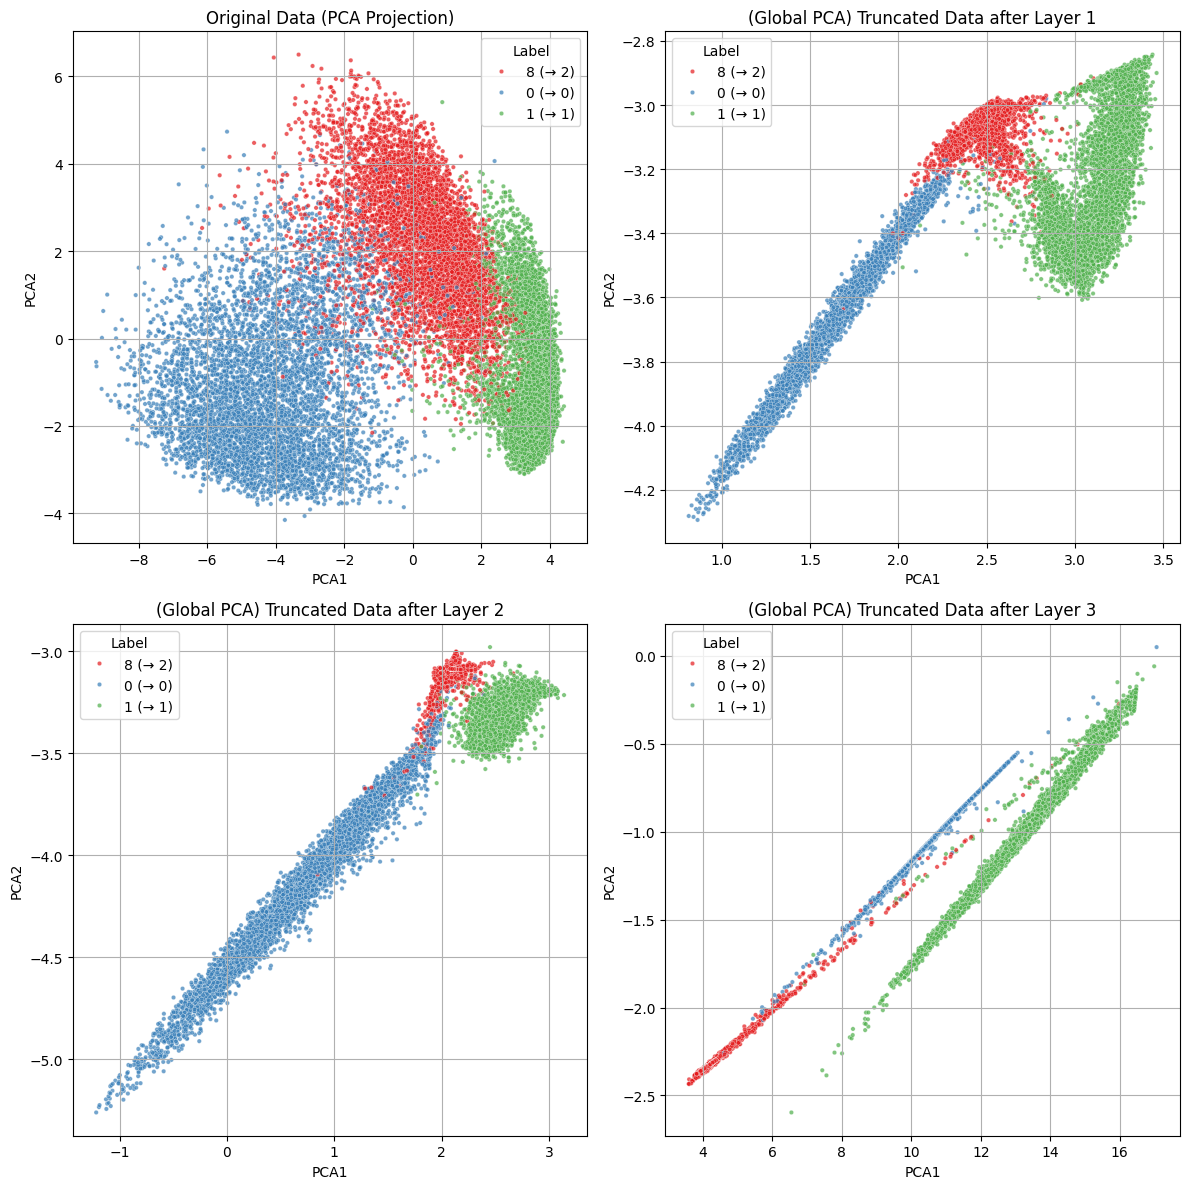

Output layer shape: (18516, 3)


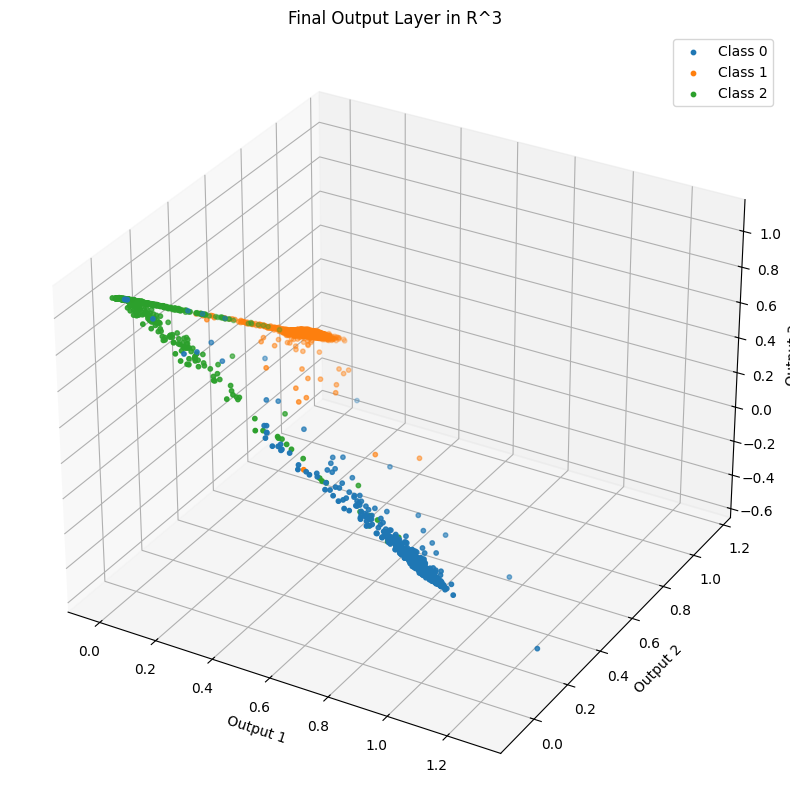

In [41]:
run_experiment([4], selected_digits=[0,1,8], plot_fn=plot_global_pca)


===== SEED 1 | DIGITS [0, 1, 8] =====
Using digits: [0, 1, 8] | Q = 3 | L = 4
Epoch 1, MSE Loss: 0.2065
Epoch 11, MSE Loss: 0.0374
Epoch 21, MSE Loss: 0.0217
Epoch 31, MSE Loss: 0.0194
Epoch 41, MSE Loss: 0.0101
Epoch 51, MSE Loss: 0.0117
Epoch 61, MSE Loss: 0.0248
Epoch 71, MSE Loss: 0.0061
Epoch 81, MSE Loss: 0.0033
Epoch 91, MSE Loss: 0.0017
Epoch 101, MSE Loss: 0.0174
Epoch 111, MSE Loss: 0.0024
Epoch 121, MSE Loss: 0.0074
Epoch 131, MSE Loss: 0.0021
Epoch 141, MSE Loss: 0.0039
Epoch 151, MSE Loss: 0.0017
Epoch 161, MSE Loss: 0.0012
Epoch 171, MSE Loss: 0.0074
Epoch 181, MSE Loss: 0.0015
Epoch 191, MSE Loss: 0.0161
Final MSE Loss: 0.002303
Test Accuracy: 99.29%

Weights Length:  4
Biases Length:  4
Truncated data for layer 1: (18516, 784)
Truncated data for layer 2: (18516, 784)
Truncated data for layer 3: (18516, 784)
Truncated data for layer 4: (18516, 784)


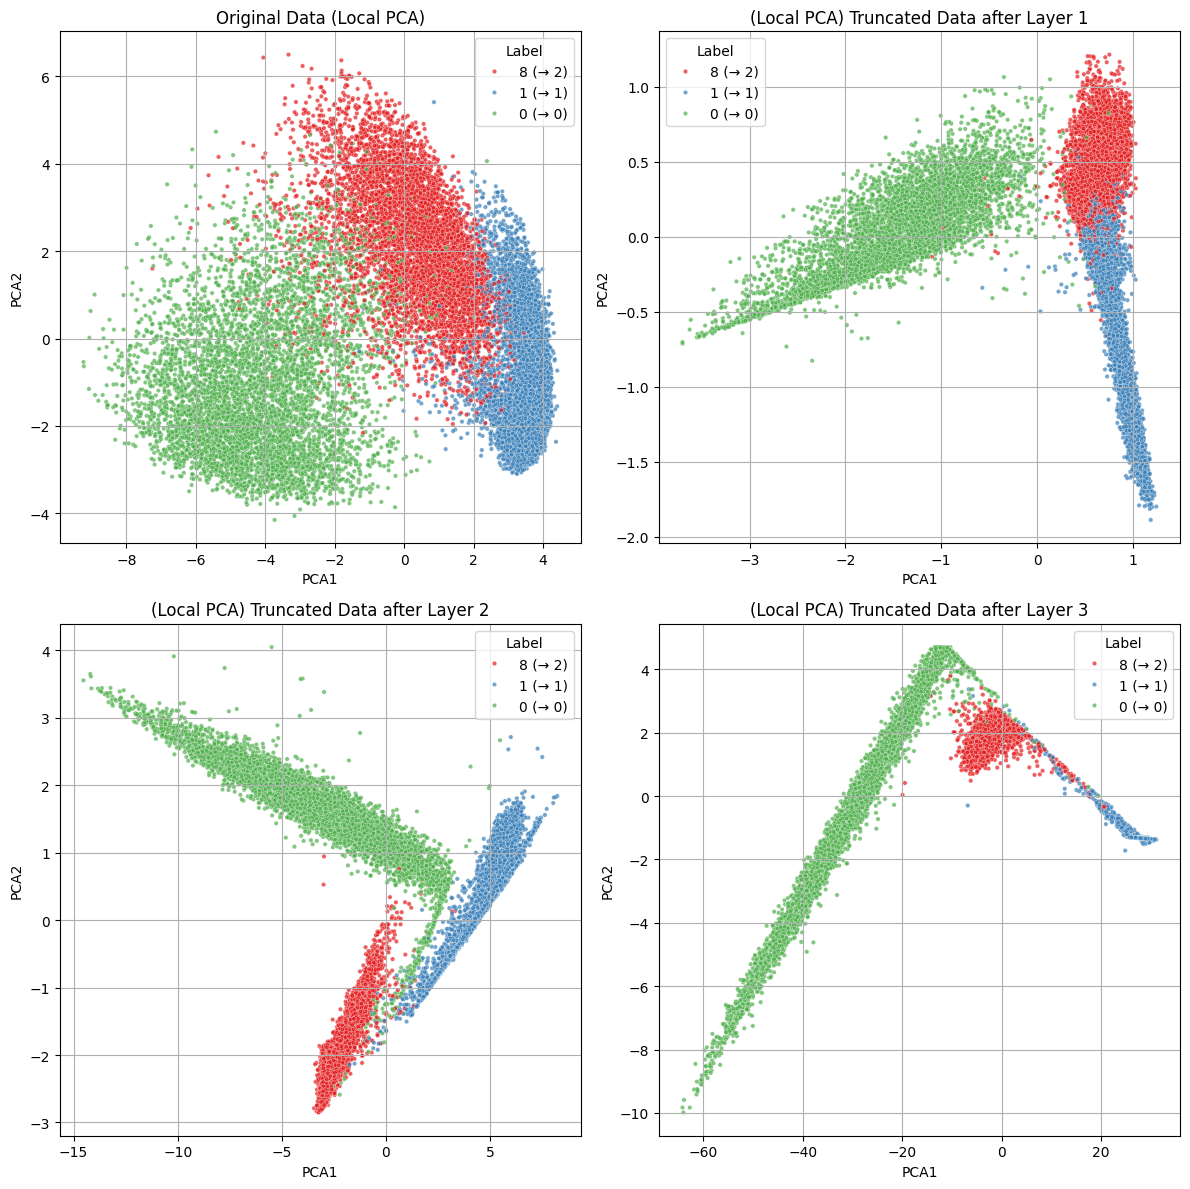

Output layer shape: (18516, 3)


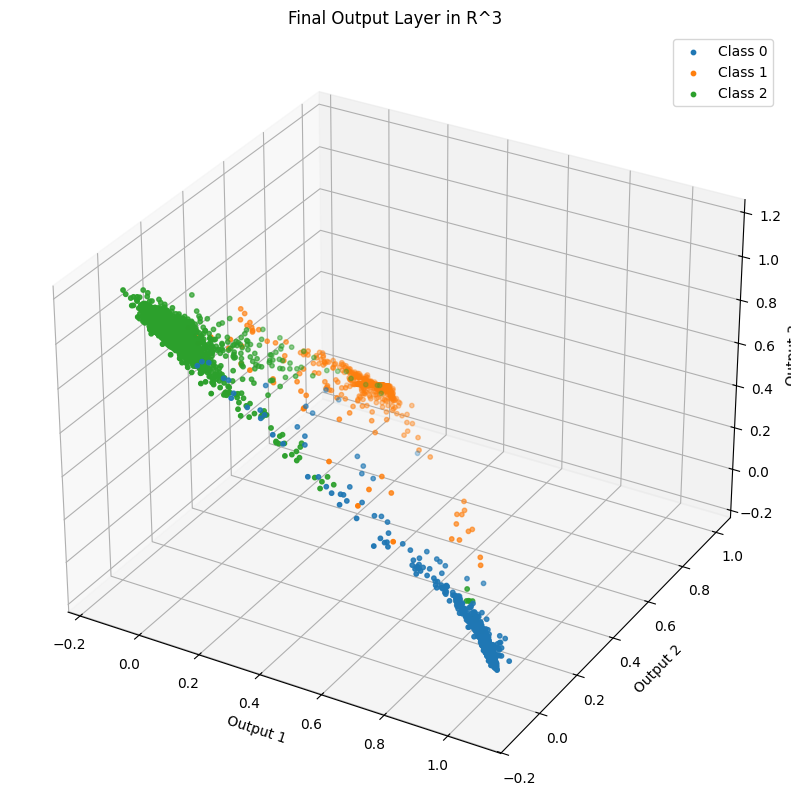

In [35]:
run_experiment([1], selected_digits=[0,1,8], plot_fn=plot_local_pca)

In [ ]:
run_experiment([0,1,2], selected_digits=[0,1,8], plot_fn=plot_lda_projection)

# **EXPERIMENTS FOR FACT 3.2**


## **TASK 1:**
> *Pick a couple of training points for each class, and visualize their truncated versions (before and after training, + link to a few clips maybe)*



## **Function Definitions**

In [ ]:
def select_points_per_class(X, y, num_per_class=1):
    selected = []
    labels = []
    indices = []

    for c in np.unique(y):
        idx_all = np.where(y == c)[0]
        idx = np.random.choice(idx_all, size=num_per_class, replace=False)

        selected.append(X[idx])
        labels.append(y[idx])
        indices.extend(idx)

    X_sel = np.vstack(selected)
    y_sel = np.concatenate(labels)

    return X_sel, y_sel, indices

In [ ]:
def track_points_through_layers(indices, X_train, X_trunc_chain):
    tracked = []

    # include original data
    tracked.append(X_train[indices])

    # then truncated layers
    for X_layer in X_trunc_chain:
        tracked.append(X_layer[indices])

    return tracked

In [ ]:
def vector_to_mnist_image(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return x.reshape(28, 28)

In [ ]:
def plot_original_images(X_sel, y_sel, label_map):
    inv_map = {v: k for k, v in label_map.items()}
    n = X_sel.shape[0]

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    if n == 1:
        axes = [axes]

    for i in range(n):
        img = vector_to_mnist_image(X_sel[i])
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"{inv_map[y_sel[i]]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_tracked_images(tracked_points, y_selected, label_map):
    inv_map = {v: k for k, v in label_map.items()}

    num_layers = len(tracked_points)
    num_points = tracked_points[0].shape[0]

    fig, axes = plt.subplots(num_points, num_layers, figsize=(2.5*num_layers, 2.5*num_points))

    if num_points == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_points):
        for ell in range(num_layers):
            img = vector_to_mnist_image(tracked_points[ell][i])

            axes[i, ell].imshow(img, cmap='gray')
            axes[i, ell].axis('off')

            if i == 0:
                axes[i, ell].set_title(f"L{ell}")

            if ell == 0:
                axes[i, ell].set_ylabel(f"{inv_map[y_selected[i]]}", rotation=0, labelpad=20)

    plt.tight_layout()
    plt.show()

## **Executing the Functions**

Using digits: [0, 1, 6, 4] | Q = 4 | L = 5




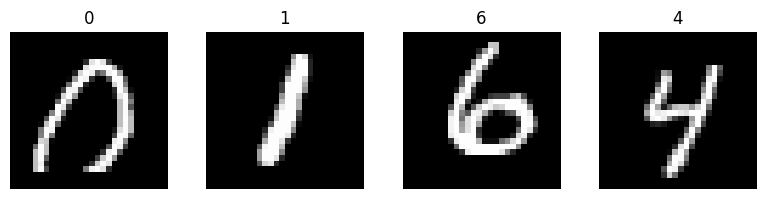

===== BEFORE TRAINING =====
Weights Length:  4
Biases Length:  4
Truncated data for layer 1: (24425, 784)
Truncated data for layer 2: (24425, 784)
Truncated data for layer 3: (24425, 784)
Truncated data for layer 4: (24425, 784)


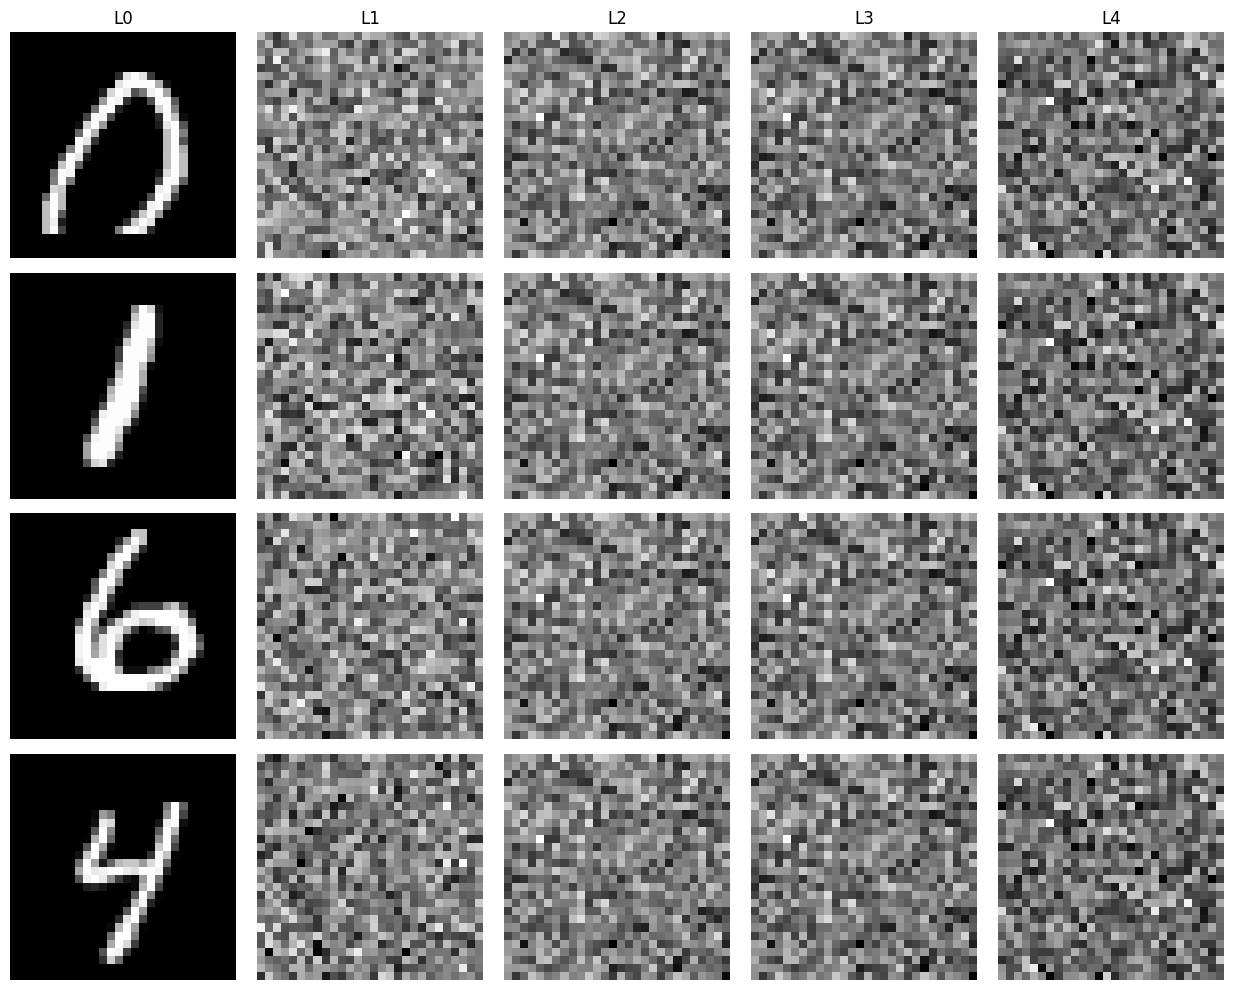

Epoch 1, MSE Loss: 0.1835
Epoch 11, MSE Loss: 0.0192
Epoch 21, MSE Loss: 0.0147
Epoch 31, MSE Loss: 0.0133
Epoch 41, MSE Loss: 0.0093
Epoch 51, MSE Loss: 0.0117
Epoch 61, MSE Loss: 0.0055
Epoch 71, MSE Loss: 0.0133
Epoch 81, MSE Loss: 0.0049
Epoch 91, MSE Loss: 0.0063
Epoch 101, MSE Loss: 0.0017
Epoch 111, MSE Loss: 0.0070
Epoch 121, MSE Loss: 0.0022
Epoch 131, MSE Loss: 0.0059
Epoch 141, MSE Loss: 0.0048
Epoch 151, MSE Loss: 0.0015
Epoch 161, MSE Loss: 0.0024
Epoch 171, MSE Loss: 0.0076
Epoch 181, MSE Loss: 0.0028
Epoch 191, MSE Loss: 0.0049
Final MSE Loss: 0.007505
Test Accuracy: 99.01%

===== AFTER TRAINING =====
Weights Length:  4
Biases Length:  4
Truncated data for layer 1: (24425, 784)
Truncated data for layer 2: (24425, 784)
Truncated data for layer 3: (24425, 784)
Truncated data for layer 4: (24425, 784)


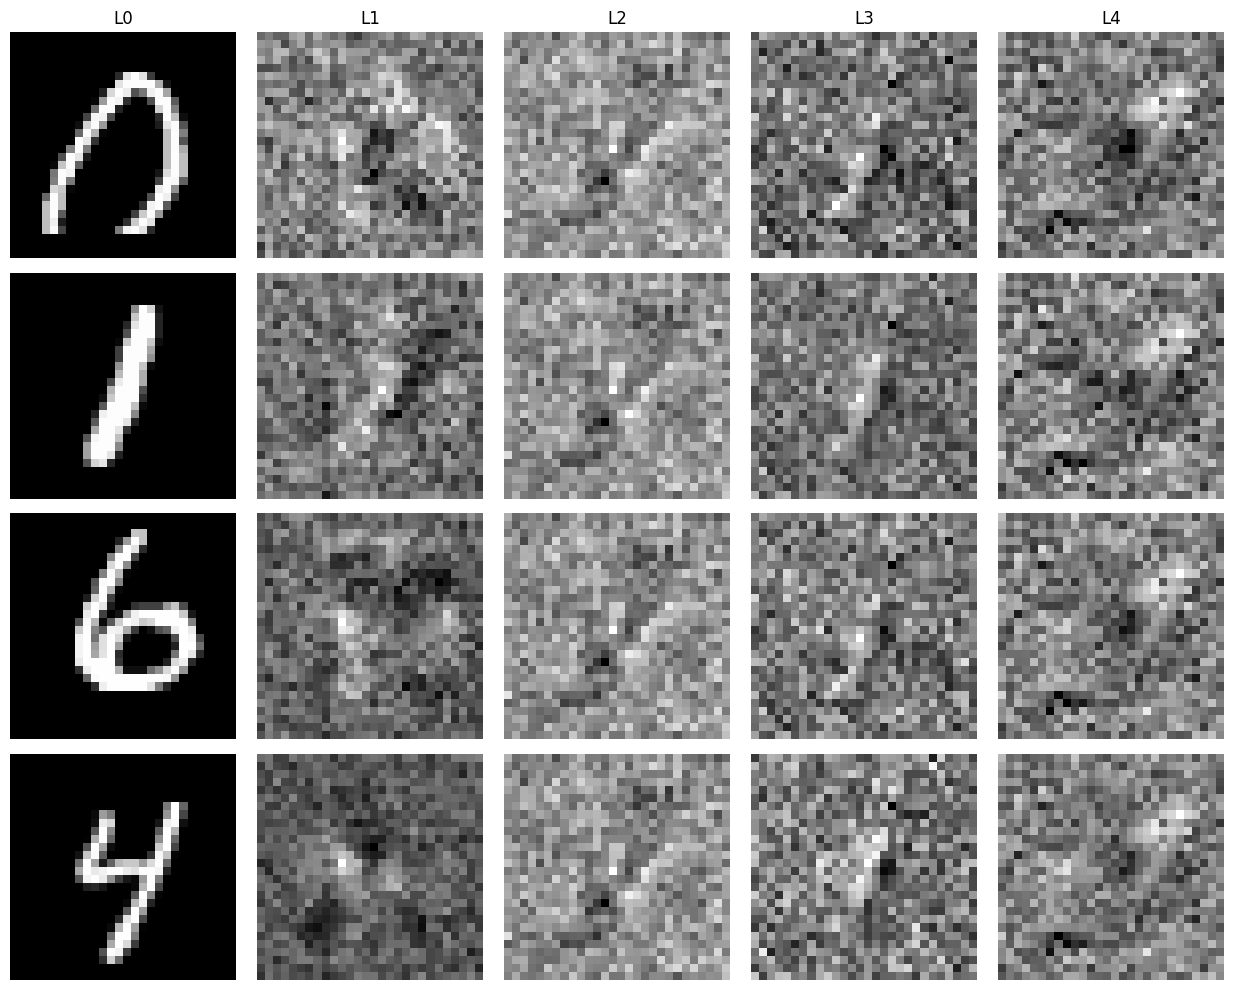

In [ ]:
train_loader, test_loader, label_map, Q, L = load_mnist_subset([0,1,6, 4])

print("")

model = ReluNet(input_dim=784, hidden_dims=[10,10,10], output_dim=Q)

print("")

# -------------------------------------------------
# Get dataset ONCE
# -------------------------------------------------
X_train, y_train = collect_dataset(train_loader)

# -------------------------------------------------
# Select SAME points for both comparisons
# -------------------------------------------------
X_sel, y_sel, indices = select_points_per_class(X_train, y_train, num_per_class=1)

plot_original_images(X_sel, y_sel, label_map)

# -------------------------------------------------
# BEFORE TRAINING
# -------------------------------------------------
print("===== BEFORE TRAINING =====")

Ws0, bs0, Wcum0, bcum0 = extract_and_compute_cumulative(model)
X_trunc_before = tau(X_train, Wcum0, bcum0)
tracked_before = track_points_through_layers(indices, X_train, X_trunc_before[:Q])
plot_tracked_images(tracked_before, y_sel, label_map)

# -------------------------------------------------
# TRAIN
# -------------------------------------------------
model, acc = train_and_evaluate(model, train_loader, test_loader, Q, epochs=200, lr=0.005, momentum=0.9)

# -------------------------------------------------
# AFTER TRAINING
# -------------------------------------------------
print("===== AFTER TRAINING =====")

Ws, bs, W_cum_chain, b_cum_chain = extract_and_compute_cumulative(model)
X_trunc_chain = tau(X_train, W_cum_chain, b_cum_chain)
tracked_after = track_points_through_layers(indices, X_train, X_trunc_chain[:Q])
plot_tracked_images(tracked_after, y_sel, label_map)

# **TASK 2:**
> *Plot the basepoint of the cone 𝑝 as an image. Compute the directing vector ℎ (the average of the unit vectors 𝑣), and plot 𝑝±𝑛𝛿ℎ for some reasonable 𝛿 and discrete values of 𝑛. Compare the results before and after training.*



## **Function Definitions**

In [ ]:
def compute_cones(W_cum, b_cum, residual_tol=1e-4):
    cones = []
    for ell, (W, b) in enumerate(zip(W_cum, b_cum)):

        # making sure everything is pure NumPy (got warning before)
        if hasattr(W, 'detach'): W = W.detach().cpu().numpy()
        if hasattr(b, 'detach'): b = b.detach().cpu().numpy()

        # compute the pseudoinverse of W
        W_pinv = np.linalg.pinv(W)

        # compute base point: p = - W^+ b [Ewa25]
        p = -W_pinv @ b

        # compute edges: v_i = W^+ e_i for standard basis vectors e_i [Ewa25]
        m = W.shape[0]
        edges = []
        edge_residuals = []

        for i in range(m):
            ei = np.zeros(m)
            ei[i] = 1
            vi = W_pinv @ ei
            edges.append(vi)

            residual = np.linalg.norm(W @ vi - ei)
            edge_residuals.append(residual)

        cones.append({'base': p, 'edges': edges})

        print(f"\n=== Layer {ell+1} Cone Checks ===")

        # # Surjectivity check (Lemma 2.1)
        rank = np.linalg.matrix_rank(W)
        rows, cols = W.shape
        # print(f"Rank(W) = {rank} | Should be full row rank = {rows}")
        # if rank == rows:
        #     print("✅ Surjective check passed, it is full row rank")
        # else:
        #     print("⚠️ Not surjective")

        # # Base point residual check
        base_residual = np.linalg.norm(W @ p + b)
        # if base_residual <= residual_tol:
        #     print(f"✅ Base point residual ||Wp + b|| = {base_residual:.2e} (OK)")
        # else:
        #     print(f"⚠️ Base point residual ||Wp + b|| = {base_residual:.2e} exceeds tolerance")

        # # Edge residuals check
        edge_residuals = np.array(edge_residuals)
        num_failed_edges = np.sum(edge_residuals > residual_tol)
        mean_edge_residual = np.mean(edge_residuals)

        # if num_failed_edges == 0:
        #   print(f"✅ All edge checks passed | Failing: {num_failed_edges}/{m} | Mean residual: {mean_edge_residual:.2e}")
        # else:
        #   print(f"⚠️ Some edge residuals exceed tolerance | Failing: {num_failed_edges}/{m} | Mean residual: {mean_edge_residual:.2e}")

        # print(f"------------------")

        # Overall pass/fail summary
        if rank == rows and base_residual <= residual_tol and num_failed_edges == 0:
            print("✅ Lemma 2.1 conditions are met")
        else:
            print("⚠️ Lemma 2.1 conditions are not met")

    return cones

In [ ]:
def get_p_h_from_cone(cones, layer_index):
    p = cones[layer_index]['base']
    edges = cones[layer_index]['edges']

    V = np.stack(edges, axis=1)  # shape (784, m)

    # normalize each edge
    V_unit = V / (np.linalg.norm(V, axis=0, keepdims=True) + 1e-8)

    # average direction
    h = np.mean(V_unit, axis=1)

    return p, h

In [ ]:
def plot_p(p, title="Base point p"):
    plt.imshow(vector_to_mnist_image(p), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
def plot_p_along_h(p, h, delta=1.0, steps=[-5, -3, -1, 0, 1, 3, 5]):
    fig, axes = plt.subplots(1, len(steps), figsize=(2*len(steps), 2))

    for i, n in enumerate(steps):
        x = p + n * delta * h
        img = vector_to_mnist_image(x)

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"{n}")
        axes[i].axis('off')

    plt.suptitle("p ± nδh")
    plt.tight_layout()
    plt.show()

## **Executing the Functions**

Using digits: [0, 1, 8] | Q = 3 | L = 4

===== BEFORE TRAINING =====
Weights Length:  4
Biases Length:  4

=== Layer 1 Cone Checks ===
✅ Lemma 2.1 conditions are met

=== Layer 2 Cone Checks ===
✅ Lemma 2.1 conditions are met

=== Layer 3 Cone Checks ===
✅ Lemma 2.1 conditions are met

=== Layer 4 Cone Checks ===
✅ Lemma 2.1 conditions are met

=== Layer 1 ===


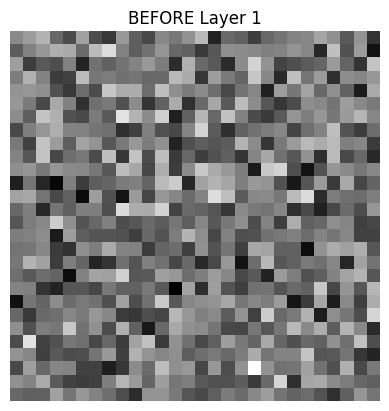

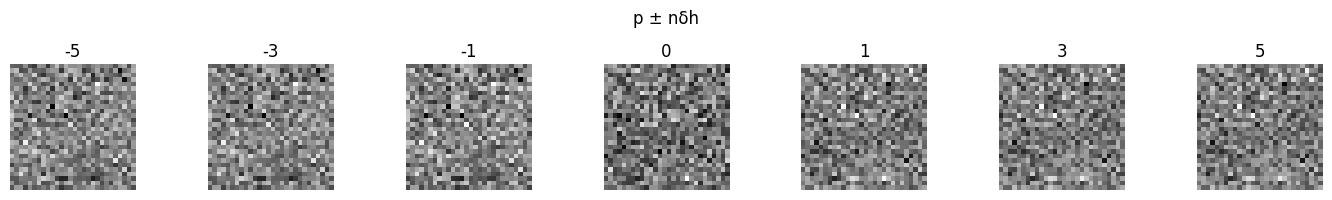


=== Layer 2 ===


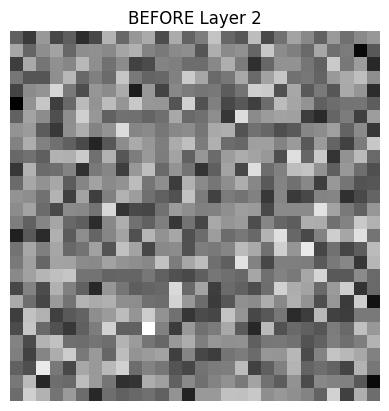

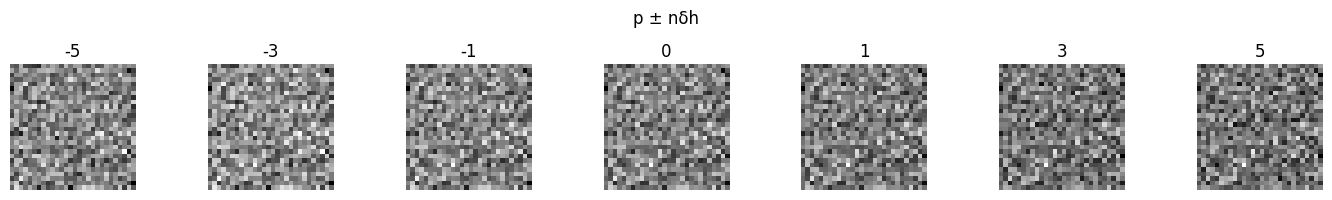


=== Layer 3 ===


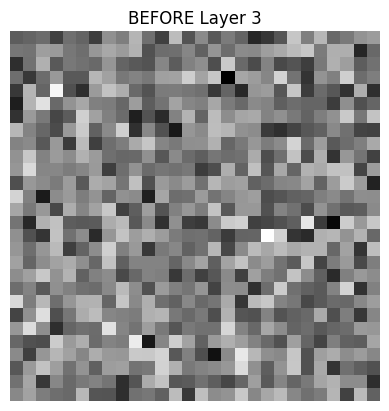

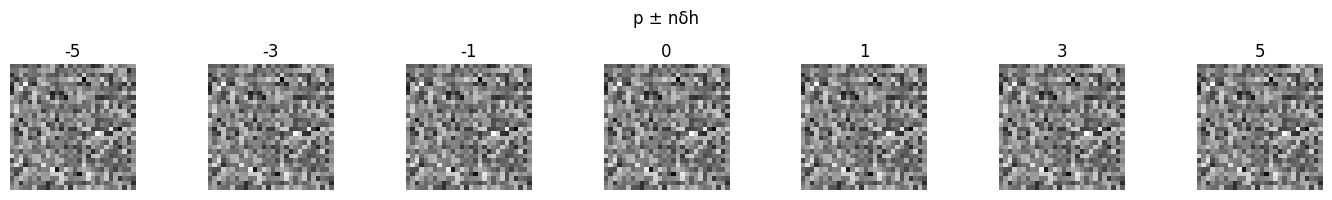

Epoch 1, MSE Loss: 0.2124
Epoch 11, MSE Loss: 0.0244
Epoch 21, MSE Loss: 0.0203
Epoch 31, MSE Loss: 0.0021
Epoch 41, MSE Loss: 0.0061
Epoch 51, MSE Loss: 0.0077
Epoch 61, MSE Loss: 0.0055
Epoch 71, MSE Loss: 0.0022
Epoch 81, MSE Loss: 0.0034
Epoch 91, MSE Loss: 0.0043
Epoch 101, MSE Loss: 0.0037
Epoch 111, MSE Loss: 0.0065
Epoch 121, MSE Loss: 0.0012
Epoch 131, MSE Loss: 0.0011
Epoch 141, MSE Loss: 0.0108
Epoch 151, MSE Loss: 0.0019
Epoch 161, MSE Loss: 0.0062
Epoch 171, MSE Loss: 0.0064
Epoch 181, MSE Loss: 0.0056
Epoch 191, MSE Loss: 0.0005
Final MSE Loss: 0.000809
Test Accuracy: 99.29%

===== AFTER TRAINING =====
Weights Length:  4
Biases Length:  4


=== Layer 1 Cone Checks ===
✅ Lemma 2.1 conditions are met

=== Layer 2 Cone Checks ===
✅ Lemma 2.1 conditions are met

=== Layer 3 Cone Checks ===
✅ Lemma 2.1 conditions are met

=== Layer 4 Cone Checks ===
✅ Lemma 2.1 conditions are met


=== Layer 1 ===


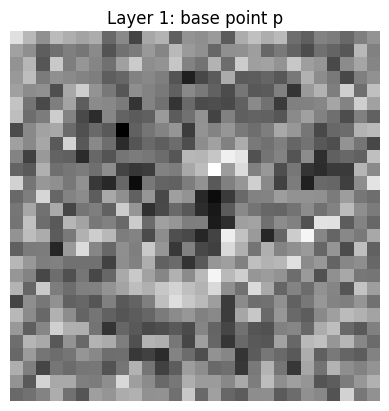

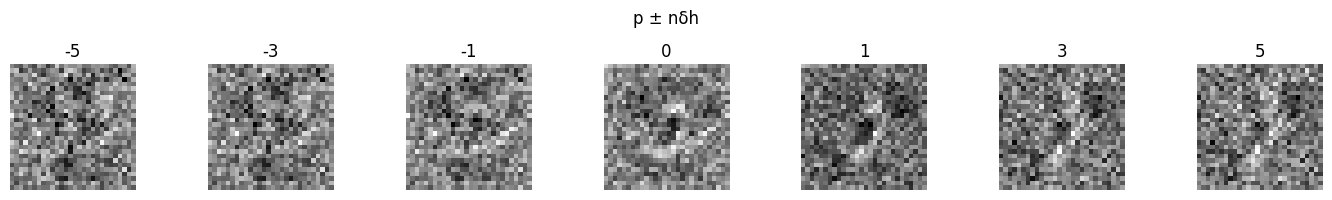


=== Layer 2 ===


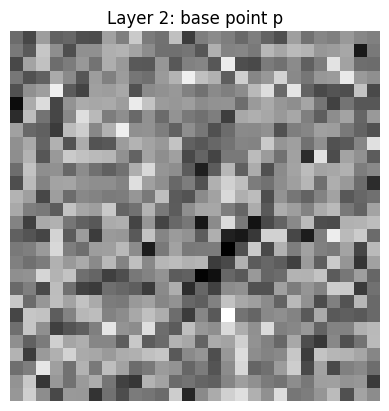

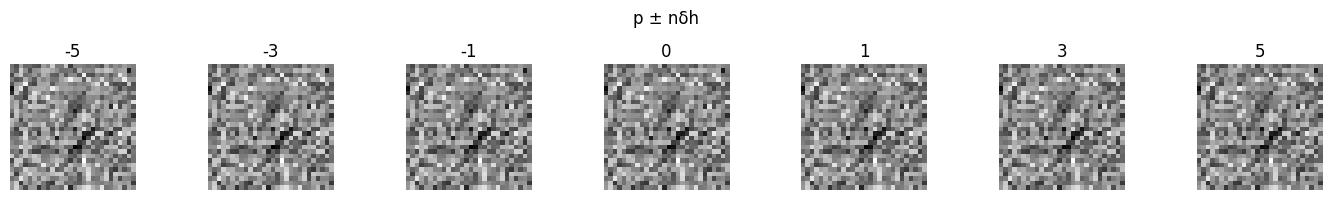


=== Layer 3 ===


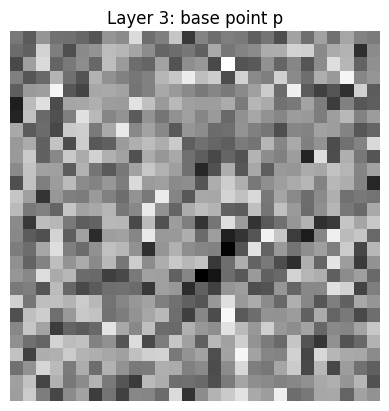

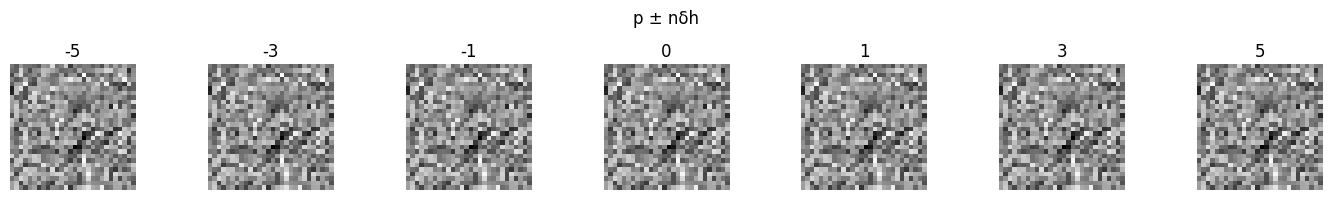

In [ ]:
train_loader, test_loader, label_map, Q, L = load_mnist_subset([0,1,8])

print("")

model = ReluNet()

# -------------------------------------------------
# BEFORE TRAINING
# -------------------------------------------------
print("===== BEFORE TRAINING =====")

Ws0, bs0, Wcum0, bcum0 = extract_and_compute_cumulative(model)

cones_before = compute_cones(Wcum0, bcum0)

for ell in range(Q):
    print(f"\n=== Layer {ell+1} ===")

    p0, h0 = get_p_h_from_cone(cones_before, ell)

    plot_p(p0, title=f"BEFORE Layer {ell+1}")
    plot_p_along_h(p0, h0)

# -------------------------------------------------
# TRAIN
# -------------------------------------------------
model, acc = train_and_evaluate(model, train_loader, test_loader, Q, epochs=200, lr=0.005, momentum=0.9)

# -------------------------------------------------
# AFTER TRAINING
# -------------------------------------------------
print("===== AFTER TRAINING =====")

Ws, bs, W_cum_chain, b_cum_chain = extract_and_compute_cumulative(model)

print("")

cones = compute_cones(W_cum_chain, b_cum_chain)

print("")

for ell in range(Q):   # Q hidden layers
    print(f"\n=== Layer {ell+1} ===")

    p, h = get_p_h_from_cone(cones, ell)

    plot_p(p, title=f"Layer {ell+1}: base point p")
    plot_p_along_h(p, h)
